In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, glob

In [17]:
files1 = glob.glob(f'/home/huangyj/representation/models_new/regression/Fold/US/LosAngeles/*/*/results.csv')
files2 = glob.glob(f'/home/huangyj/representation/models_new/regression/Fold/US/LosAngeles/*/*/result.csv')
files = files1 + files2
len(files)

10

In [18]:
ls = []
for i, file in enumerate(files):
    model = file.split('/')[-2]
    tmp = pd.read_csv(file)
    if 'avg_r2' in tmp.columns:
        tmp = tmp[['avg_r2']]
        tmp = tmp.rename(columns={'avg_r2': model})
    else:
        tmp = tmp[['r2']]
        tmp = tmp.rename(columns={'r2': model})
    ls.append(tmp)
df = pd.concat(ls, axis=1)
targets = [
    'logcrime', 'logpetty', 'walkbike_per_cbg', 'publictrans_per_cbg', 'drove_alone_per_cbg', 'estvmiles' ,
    'estpmiles', 'estvtrp', 'estptrp', 'obesitycru', 'diabetescr', 'lpacrudepr', 
    'mhlthcrude','phlthcrude','cancercrud','mhincome_cbg','povertyline_below100','povertyline_below200'
]
df['target'] = targets
df

,Attn_Mocov3VITB-prebuffer-cbg-LosAngeles-ep99,SV_RSNgb_moe,SV_RScbg_Concat,SV_RSNgb_Concat,SV_RScbg_moe,queen,rook,mocov3_vitb_300ep_rs_la_T2024_Neighbor,mocov3_vitb_300ep_rs_la_T2024_cbg,Mocov3VITB-prebuffer-cbg-LosAngeles-ep99,target
0,0.365449,0.438270,0.430720,0.430720,0.446820,0.233951,0.169793,0.386907,0.376272,0.430720,logcrime
1,0.094078,0.239730,0.203174,0.203174,0.243741,0.091382,0.044241,0.143953,0.149630,0.203177,logpetty
2,0.281147,0.231248,0.256801,0.256801,0.234777,0.096215,0.065556,0.269640,0.208882,0.256800,walkbike_per_cbg
3,0.571415,0.549514,0.552774,0.552774,0.555149,0.222423,0.184410,0.501448,0.464147,0.552775,publictrans_per_cbg
4,0.121497,0.346791,0.347468,0.347468,0.347905,0.153697,0.135605,0.332057,0.310783,0.347469,drove_alone_per_cbg
5,0.560046,0.650302,0.662973,0.662973,0.658753,0.227746,0.188100,0.650779,0.622176,0.662973,estvmiles
6,0.464487,0.625576,0.646107,0.646107,0.638618,0.225112,0.196414,0.622939,0.588997,0.646107,estpmiles
7,0.512949,0.687054,0.698663,0.698663,0.696064,0.293920,0.228470,0.689051,0.658235,0.698663,estvtrp
8,0.375453,0.637770,0.647135,0.647135,0.646208,0.266614,0.233578,0.637200,0.586166,0.647135,estptrp
9,0.757106,0.801604,0.812310,0.812310,0.799287,0.249930,0.245448,0.771154,0.689001,0.812311,obesitycru


In [19]:
df.columns

Index(['Attn_Mocov3VITB-prebuffer-cbg-LosAngeles-ep99', 'SV_RSNgb_moe',
       'SV_RScbg_Concat', 'SV_RSNgb_Concat', 'SV_RScbg_moe', 'queen', 'rook',
       'mocov3_vitb_300ep_rs_la_T2024_Neighbor',
       'mocov3_vitb_300ep_rs_la_T2024_cbg',
       'Mocov3VITB-prebuffer-cbg-LosAngeles-ep99', 'target'],
      dtype='object')

In [20]:
df.columns = [
    'SV-Attn', 'SVRSngb-MOE','SVRScbg-Concat', 'SVRSngb-Concat', 'SVRScbg-MOE',
    'Spatial-Queen', 'Spatial-Rook', 'RS-Neighbor', 
    'RS-cbg', 'SV-Lasso',  'target'
]
df = df[[
    'target', 
    'SV-Attn', 'SV-Lasso', 
    'RS-Neighbor', 'RS-cbg', 
    'Spatial-Queen', 'Spatial-Rook', 
    'SVRScbg-Concat', 'SVRSngb-Concat', 'SVRScbg-MOE', 'SVRSngb-MOE'
]]

In [21]:
df.drop(columns=[
    # 'target', 
    # 'SV-Attn', 'SV-Lasso', 
    # 'RS-Neighbor', 'RS-cbg', 
    'Spatial-Queen', 'Spatial-Rook', 
    # 'SVRScbg-Concat', 
    'SVRSngb-Concat', 
    # 'SVRScbg-MOE', 
    'SVRSngb-MOE'
], inplace=True)

/tmp/ipykernel_568379/707893779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=[


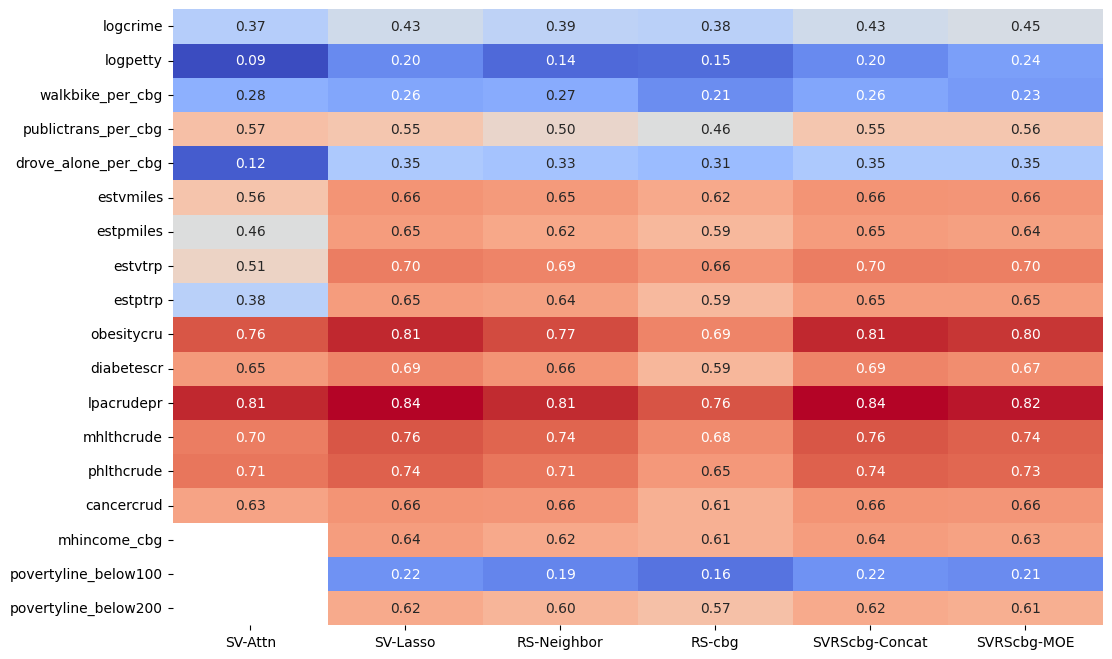

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.set_index('target'), annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.ylabel('')
plt.show()